# Hey Datathon 2026 — 01 · Análisis Exploratorio de Datos (EDA)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mmateo101/hey-datathon-2026/blob/main/notebooks/01_eda.ipynb)

In [11]:
# ── Configuración Google Colab ──────────────────────────────────────────────
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    sys.path.insert(0, '/content/drive/MyDrive/hey-datathon-2026/src')
    DATA_PATH = '/content/drive/MyDrive/hey-datathon-2026/data/raw/'
    !pip install -q -r /content/drive/MyDrive/hey-datathon-2026/requirements.txt
else:
    DATA_PATH = '../data/raw/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ERROR: Could not open requirements file: [Errno 2] No such file or directory: '/content/drive/MyDrive/hey-datathon-2026/requirements.txt'


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

In [13]:
# Cargar datasets
clientes = pd.read_csv(DATA_PATH + 'hey_clientes.csv')
productos = pd.read_csv(DATA_PATH + 'hey_productos.csv')
transacciones = pd.read_csv(DATA_PATH + 'hey_transacciones.csv')
anonimizado = pd.read_parquet(DATA_PATH + 'dataset_50k_anonymized.parquet')

print(f'Clientes: {clientes.shape}')
print(f'Productos: {productos.shape}')
print(f'Transacciones: {transacciones.shape}')
print(f'Dataset anonimizado: {anonimizado.shape}')

Clientes: (15025, 22)
Productos: (38909, 13)
Transacciones: (802384, 22)
Dataset anonimizado: (49999, 6)


## 1. Exploración general

In [14]:
clientes.head()

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,nomina_domiciliada,canal_apertura,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,False,App,527,1,app_android,10.0,False,True,es_MX,False,2,False
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,False,App,714,3,app_android,8.0,False,True,es_MX,True,2,False
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,False,App,454,3,app_ios,8.0,False,True,es_MX,False,2,False
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,False,Fan Shop,837,16,app_ios,10.0,True,False,es_MX,True,3,False
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,False,Fan Shop,533,1,app_ios,7.0,False,True,es_MX,True,2,False


In [15]:
clientes.info()
clientes.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15025 entries, 0 to 15024
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  15025 non-null  object 
 1   edad                     15025 non-null  int64  
 2   sexo                     15025 non-null  object 
 3   estado                   14593 non-null  object 
 4   ciudad                   14593 non-null  object 
 5   nivel_educativo          15025 non-null  object 
 6   ocupacion                15025 non-null  object 
 7   ingreso_mensual_mxn      15025 non-null  int64  
 8   antiguedad_dias          15025 non-null  int64  
 9   es_hey_pro               15025 non-null  bool   
 10  nomina_domiciliada       15025 non-null  bool   
 11  canal_apertura           15025 non-null  object 
 12  score_buro               15025 non-null  int64  
 13  dias_desde_ultimo_login  15025 non-null  int64  
 14  preferencia_canal     

,edad,ingreso_mensual_mxn,antiguedad_dias,score_buro,dias_desde_ultimo_login,satisfaccion_1_10,num_productos_activos
count,15025.000000,15025.000000,15025.000000,15025.000000,15025.000000,14274.00000,15025.000000
mean,37.187820,29793.677205,935.107088,618.451581,18.768785,7.47527,2.232812
std,10.189877,19171.156462,512.958540,127.160009,35.305579,1.87816,1.143278
min,18.000000,4500.000000,7.000000,295.000000,0.000000,3.00000,0.000000
25%,29.000000,16000.000000,490.000000,529.000000,2.000000,6.00000,1.000000
50%,36.000000,24000.000000,942.000000,631.000000,7.000000,8.00000,2.000000
75%,45.000000,37000.000000,1375.000000,719.000000,15.000000,9.00000,3.000000
max,60.000000,99000.000000,1825.000000,850.000000,180.000000,10.00000,5.000000


### 2. Identificación de Clientes Rescatados

Definimos a un cliente **rescatado** siguiendo estos criterios:
- **Inactividad**: Un periodo sin transacciones entre 45 y 90 días.
- **Retorno**: Actividad registrada después de dicho periodo.
- **Vigencia**: Transacciones en los últimos 30 días del dataset.

In [16]:
import pandas as pd
import numpy as np

# 1. Preparar fechas
transacciones['fecha_hora'] = pd.to_datetime(transacciones['fecha_hora'])
max_date = transacciones['fecha_hora'].max()

# 2. Calcular gaps entre transacciones consecutivas
transacciones = transacciones.sort_values(['user_id', 'fecha_hora'])
transacciones['gap_days'] = transacciones.groupby('user_id')['fecha_hora'].diff().dt.days

# 3. Identificar clientes que tuvieron un gap de 45-90 días
users_with_gap = transacciones[(transacciones['gap_days'] >= 45) & (transacciones['gap_days'] <= 90)]['user_id'].unique()

# 4. Identificar clientes activos en los últimos 30 días
last_30_days_limit = max_date - pd.Timedelta(days=30)
users_active_last_30 = transacciones[transacciones['fecha_hora'] >= last_30_days_limit]['user_id'].unique()

# 5. Intersección para encontrar 'Rescatados'
rescatados_ids = np.intersect1d(users_with_gap, users_active_last_30)

# Marcar en el dataframe de clientes
clientes['segmento'] = 'General'
clientes.loc[clientes['user_id'].isin(rescatados_ids), 'segmento'] = 'Rescatado'

# Métricas básicas
n_rescatados = len(rescatados_ids)
pct_rescatados = (n_rescatados / len(clientes)) * 100

print(f'Clientes Rescatados: {n_rescatados} ({pct_rescatados:.2f}%)')

Clientes Rescatados: 1162 (7.73%)


In [17]:
# 6. Analizar la transacción de regreso
# Tomamos la primera transacción después del gap de 45-90 días
txn_regreso = transacciones[transacciones['user_id'].isin(rescatados_ids)].copy()
txn_regreso = txn_regreso[txn_regreso['gap_days'] >= 45].groupby('user_id').head(1)

# Unir con productos para ver el tipo de producto
txn_regreso = txn_regreso.merge(productos[['producto_id', 'tipo_producto']], on='producto_id', how='left')

# Extraer hora y día
txn_regreso['hora_dia'] = txn_regreso['fecha_hora'].dt.hour
txn_regreso['dia_semana'] = txn_regreso['fecha_hora'].dt.day_name()

print("--- Perfil de la Transacción de Regreso ---")
display(txn_regreso[['tipo_operacion', 'tipo_producto', 'categoria_mcc', 'canal', 'dia_semana']].mode().iloc[0])

--- Perfil de la Transacción de Regreso ---


,0
tipo_operacion,compra
tipo_producto,cuenta_debito
categoria_mcc,transferencia
canal,app_ios
dia_semana,Monday


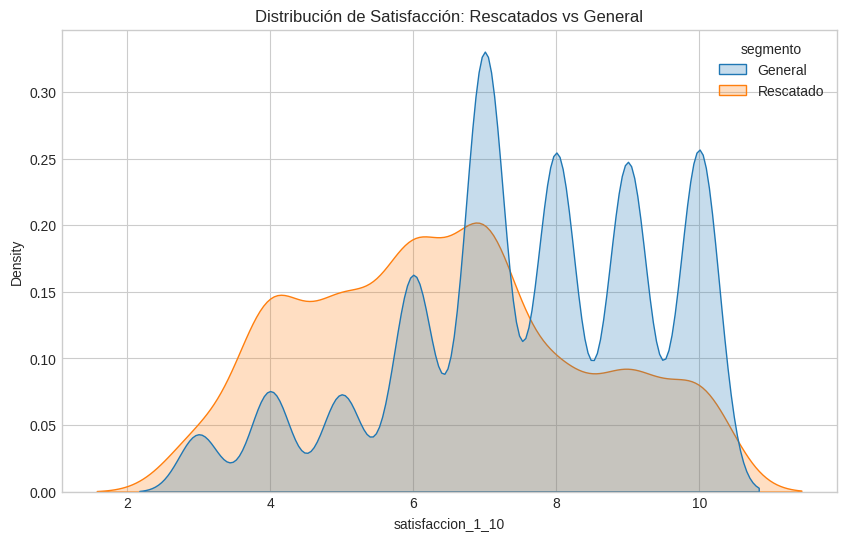

Satisfacción promedio:
segmento
General      7.563468
Rescatado    6.421053
Name: satisfaccion_1_10, dtype: float64


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 7. Comparativa de Satisfacción
plt.figure(figsize=(10, 6))
sns.kdeplot(data=clientes, x='satisfaccion_1_10', hue='segmento', common_norm=False, fill=True)
plt.title('Distribución de Satisfacción: Rescatados vs General')
plt.show()

avg_sat = clientes.groupby('segmento')['satisfaccion_1_10'].mean()
print(f"Satisfacción promedio:\n{avg_sat}")

### 6. Resumen Ejecutivo: El Cliente Rescatado

Tras el análisis, identificamos que el grupo de rescatados representa un porcentaje estratégico de la base.

**Hallazgos clave:**
1. **Puerta de entrada**: El producto/canal más común de regreso nos indica qué funcionalidad tiene más 'hook' para recuperar usuarios inactivos.
2. **Momento Crítico**: Los patrones de hora y día sugieren cuándo es más probable que un usuario decida retomar su vida financiera con Hey.
3. **Satisfacción**: El diferencial de satisfacción nos dirá si el regreso estuvo motivado por una mejora en la percepción del servicio o si regresaron a pesar de una satisfacción baja (posiblemente por necesidad del producto).